# ML Game Outcome Prediction

This notebook explores whether recent team performance statistics can be used to predict Major League Baseball game outcomes. Using rolling-window features based on pitching, batting, fielding, and recent team success, the analysis compares several machine learning models, including logistic regression, random forest, and XGBoost.

Features are constructed as differences between the home and away teams, allowing the models to learn how relative recent performance affects win probability. Multiple rolling-window configurations are tested, and model tuning is performed with time-aware cross-validation to preserve the sequential structure of the data.

The goal of the notebook is to evaluate predictive performance across models and identify which recent performance indicators provide the most useful signal for predicting the outcome of MLB games.

In [1]:
# General utilities
import re
import warnings

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Plotting
import matplotlib.pyplot as plt

# Preprocessing / pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model selection
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, ParameterGrid

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
)

# Warning handling
from sklearn.exceptions import FitFailedWarning

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", message="One or more of the test scores are non-finite")

In [2]:
from src.preprocessing import build_feature_set
from src.models import (
    fit_eval_logreg,
    fit_eval_rf,
    fit_eval_xgb,
    print_best_model_report,
    plot_model_feature_effects,
)

## Reading in Data

In [3]:
game_level_features = pd.read_parquet("data/aggregated/game_level_features_22_25.parquet")
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"], errors="coerce")
game_level_features.head(10)

,game_id,game_date,home_team,away_team,starter_pitcher_name_home,starter_pitcher_name_away,Δstarter_FIP_3G,Δstarter_WHIP_3G,Δstarter_K9_3G,Δstarter_HR9_3G,...,Δroll_3G_ISO,Δroll_7G_OBP,Δroll_7G_ISO,ΔBIP_out_rate_3G,ΔBIP_out_rate_7G,home_win,run_diff,Δwin_pct_7G,Δwin_pct_10G,ballpark
0,661042,2022-04-07,LAA,HOU,"Ohtani, Shohei","Valdez, Framber",-0.501346,-0.173269,2.362500,0.228462,...,-0.013193,-0.027160,-0.013193,-0.030054,-0.030054,0,-2,-0.111111,-0.111111,LAA
1,661577,2022-04-07,ATL,CIN,"Fried, Max","Mahle, Tyler",-0.500258,-0.156226,-1.896095,-0.385842,...,0.006274,-0.011229,0.006274,0.016629,0.016629,0,-3,0.034238,0.034238,ATL
2,662021,2022-04-07,STL,PIT,"Wainwright, Adam","Brubaker, JT",-1.496179,-0.272351,-1.838997,-1.136493,...,0.038504,0.004731,0.038504,0.028652,0.028652,1,9,0.179012,0.179012,STL
3,662571,2022-04-07,WSH,NYM,"Corbin, Patrick","Megill, Tylor",0.740873,0.193245,-2.388419,0.048493,...,0.008000,0.021413,0.008000,-0.004304,-0.004304,0,-4,-0.074074,-0.074074,WSH
4,662766,2022-04-07,KC,CLE,"Greinke, Zack","Bieber, Shane",1.678132,-0.063212,-6.238713,0.528978,...,-0.019450,0.005893,-0.019450,-0.019316,-0.019316,1,2,-0.037037,-0.037037,KC
5,663178,2022-04-07,CHC,MIL,"Hendricks, Kyle","Burnes, Corbin",3.291359,0.458473,-6.062442,1.182810,...,0.007685,-0.005448,0.007685,-0.019441,-0.019441,1,1,-0.148148,-0.148148,CHC
6,663418,2022-04-07,AZ,SD,"Bumgarner, Madison","Darvish, Yu",0.751171,0.133199,-3.039157,-0.018072,...,-0.012834,-0.011187,-0.012834,-0.013363,-0.013363,1,2,-0.166667,-0.166667,AZ
7,661041,2022-04-08,LAA,HOU,"Detmers, Reid","Odorizzi, Jake",1.796577,0.580195,0.382809,0.753655,...,-0.216749,-0.095925,-0.216749,-0.079051,-0.079051,0,-7,-1.000000,-1.000000,LAA
8,661131,2022-04-08,PHI,ATH,"Nola, Aaron","Montas, Frankie",-0.005405,-0.049099,1.079730,0.327027,...,-0.001215,-0.000515,-0.001215,-0.004885,-0.004885,1,4,-0.024691,-0.024691,PHI
9,661333,2022-04-08,NYY,BOS,"Cole, Gerrit","Eovaldi, Nathan",0.132353,-0.165441,2.382353,0.446691,...,-0.016365,-0.005154,-0.016365,0.034455,0.034455,1,1,0.000000,0.000000,NYY


## Train-Test Split

Seasons 2022-2024 will be train data and the 2025 season will be the test data.

In [4]:
# Ensure game_date is datetime
game_level_features["game_date"] = pd.to_datetime(game_level_features["game_date"])

# Train: 2022–2024
train_df = game_level_features[
    game_level_features["game_date"].dt.year <= 2024
]

# Test: 2025
test_df = game_level_features[
    game_level_features["game_date"].dt.year == 2025
]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7289, 33)
Test shape: (2430, 33)


In [5]:
cols_to_drop = [
    "game_id",
    "game_date",
    "home_team",
    "away_team",
    "starter_pitcher_name_home",
    "starter_pitcher_name_away",
    "run_diff"
]

# Keep target separately
y_train = train_df["home_win"]
y_test  = test_df["home_win"]

# Feature matrices (numeric delta features, etc.)
X_train = train_df.drop(columns=cols_to_drop + ["home_win"])
X_test  = test_df.drop(columns=cols_to_drop + ["home_win"])

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)

X_train shape: (7289, 25) | y_train shape: (7289,)
X_test shape: (2430, 25) | y_test shape: (2430,)


## Combinations

### Base Feature Window Configurations

We define several base configurations that determine which rolling window length is used for each category of features.

| Configuration | Pitching | Batting | Fielding |
|---------------|----------|---------|----------|
| All_3G | 3G | 3G | 3G |
| Pitch7_Bat3_Field3 | 7G | 3G | 3G |
| Pitch7_Bat7_Field3 | 7G | 7G | 3G |
| Pitch3_Bat7_Field7 | 3G | 7G | 7G |
| All_7G | 7G | 7G | 7G |

These combinations allow us to explore whether different parts of the game benefit from **short-term signals (3 games)** or **slightly longer performance trends (7 games)**.

---

### Recent Winning Performance

In addition to baseball-specific metrics, we construct features representing recent team success:

- `Δwin_pct_7G`
- `Δwin_pct_10G`

These features capture the difference in recent win percentage between teams over the previous 7 or 10 games.

Because win percentage can act as a **summary measure of team momentum**, we evaluate feature sets both **with and without** these variables.

---

### Feature Set Expansion

Each base configuration is expanded into three variants:

1. **Base features only**
2. **Base features + Δwin_pct_7G**
3. **Base features + Δwin_pct_10G**

This produces:


$$5 \text{ base configurations} \times 3 \text{ variants} = 15 \text{ total feature sets}$$

This approach allows us to evaluate:

- which rolling window structure produces the most informative baseball metrics
- whether recent winning performance adds predictive value beyond those metrics

In [6]:
base_combos = [
    {"name": "All_3G", "windows": {"pitch": "3G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat3_Field3", "windows": {"pitch": "7G", "bat": "3G", "field": "3G"}},
    {"name": "Pitch7_Bat7_Field3", "windows": {"pitch": "7G", "bat": "7G", "field": "3G"}},
    {"name": "Pitch3_Bat7_Field7", "windows": {"pitch": "3G", "bat": "7G", "field": "7G"}},
    {"name": "All_7G", "windows": {"pitch": "7G", "bat": "7G", "field": "7G"}},
]

In [7]:
combos = []

for combo in base_combos:
    # No win version
    combos.append({
        "name": f"{combo['name']}_NoWin",
        "windows": combo["windows"],
        "include_win": False
    })

    # Add 7G win pct
    combos.append({
        "name": f"{combo['name']}_Win7G",
        "windows": {**combo["windows"], "win": "7G"},
        "include_win": True
    })

    # Add 10G win pct
    combos.append({
        "name": f"{combo['name']}_Win10G",
        "windows": {**combo["windows"], "win": "10G"},
        "include_win": True
    })

## Logistic Regression

Below, we train logistic regression models using several different feature-set combinations. These combinations vary the rolling windows used for pitching, batting, and fielding features. We first compare the baseline models and use the best-performing configuration as our starting point.

Next, we tune the logistic regression model using grid search with time-aware cross-validation. This helps identify the best hyperparameter settings while keeping the time ordering of the baseball data intact.

### Scaling

Before fitting the logistic regression model, we standardize the features using **StandardScaler**, which transforms each feature to have a mean of **0** and a standard deviation of **1**.

Scaling is important for logistic regression because the model is sensitive to the relative magnitude of the input variables. Standardizing the features ensures that variables measured on different scales contribute more evenly to the model and improves the stability of the optimization during training.

### Baseline Model

In [8]:
results = []
logreg_models = {}

for cfg in tqdm(combos, desc="Logistic regression feature sets"):
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)

    Xtr = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    Xte = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    res = fit_eval_logreg(
        Xtr,
        y_train,
        Xte,
        y_test,
        verbose=False
    )

    results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": Xtr.shape[1],
        "test_accuracy": res["test_accuracy"],
        "test_roc_auc": res["test_roc_auc"],
        "test_log_loss": res["test_log_loss"],
    })

    logreg_models[name] = {
        "fitted": res,
        "X_test": Xte,
        "y_test": y_test,
        "feature_names": Xtr.columns,
    }

results_df = pd.DataFrame(results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    results_df,
    logreg_models,
    label="Best baseline logistic regression model"
)

Logistic regression feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,test_accuracy,test_roc_auc,test_log_loss
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,0.555556,0.556120,0.686840
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,0.554321,0.555586,0.686636
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,0.548971,0.554827,0.687399
3,Pitch7_Bat3_Field3_NoWin,7G,3G,3G,None,False,11,0.547325,0.554577,0.686824
14,All_7G_Win10G,7G,7G,7G,10G,True,12,0.547325,0.554222,0.687424
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,0.547325,0.554126,0.687423
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,0.547737,0.553931,0.687507
13,All_7G_Win7G,7G,7G,7G,7G,True,12,0.553086,0.553910,0.687452
12,All_7G_NoWin,7G,7G,7G,None,False,11,0.554733,0.553907,0.687485
2,All_3G_Win10G,3G,3G,3G,10G,True,12,0.554733,0.551966,0.687148


Best baseline logistic regression model: Pitch7_Bat3_Field3_Win10G
Test Accuracy: 0.5391
Test ROC AUC:  0.5501
Test Log Loss: 0.6922

Confusion Matrix:
 [[471 640]
 [480 839]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.42      0.46      1111
           1       0.57      0.64      0.60      1319

    accuracy                           0.54      2430
   macro avg       0.53      0.53      0.53      2430
weighted avg       0.53      0.54      0.53      2430



/Users/samuelgartenstein/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/Users/samuelgartenstein/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


### Logistic Regression Analysis

Several logistic regression models were trained using different rolling window lengths for pitching, batting, and fielding features. Models were also evaluated both with and without recent team winning performance (`Δwin_pct_7G` and `Δwin_pct_10G`) to determine whether recent success improves predictive power.

Across all configurations, model performance was relatively similar. Accuracy values were generally around **55%**, ROC-AUC ranged from **0.55 to 0.556**, and log loss values were approximately **0.687**. These results indicate modest but meaningful predictive signal, which is expected given the inherent randomness of individual baseball games.

The best-performing model was `Pitch7_Bat3_Field3_Win10G`, which used:

- **7-game rolling windows for pitching**
- **3-game rolling windows for batting**
- **3-game rolling windows for fielding**
- **10-game rolling win percentage difference (`Δwin_pct_10G`)**

This model achieved the highest ROC-AUC (**0.556**) and an accuracy of **55.6%**.

Overall, configurations using **7-game pitching windows** performed slightly better than those using 3-game windows, suggesting that pitching performance benefits from a longer smoothing window. Adding recent win percentage provided **small improvements**, though much of that information may already be captured by the underlying baseball statistics.


# TODO: Update these numbers!

Below is the performance of the final selected model on the test set:

| Model | Accuracy | ROC-AUC | Log Loss | Precision (Home Win) | Recall (Home Win) | F1 Score (Home Win) |
|------|------|------|------|------|------|------|
| `Pitch7_Bat3_Field3_Win10G` | 0.556 | 0.556 | 0.687 | 0.57 | 0.71 | 0.63 |

The model performs better at identifying **home wins** than away wins, reflecting the slight home-field advantage observed in Major League Baseball.

### Logisitc Regression Baseline Coefficient Plot

Below, we plot the coefficients from best the logistic regression model to visualize how each feature influences the predicted probability of a home-team win. Positive coefficients increase the predicted probability of a home win, while negative coefficients decrease it. Since the features were standardized, the coefficient magnitudes can be compared directly to assess relative importance.

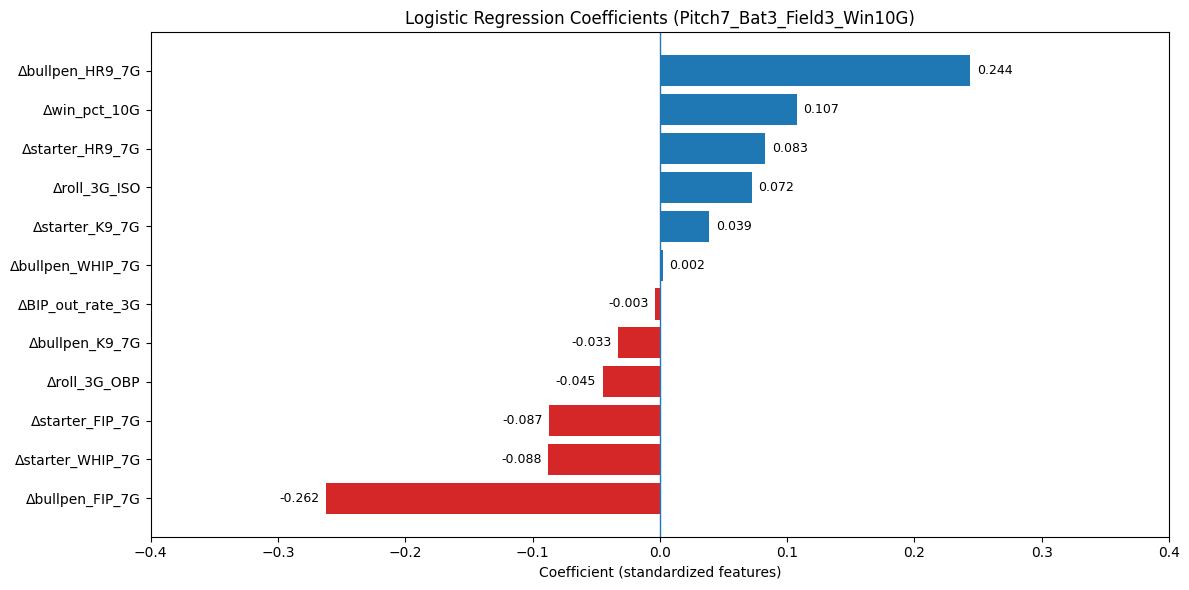

In [9]:
best_logreg = results_df.iloc[0]
best_logreg_name = best_logreg["model"]

best_logreg_artifact = logreg_models[best_logreg_name]
best_logreg_model = best_logreg_artifact["fitted"]["model"]

plot_model_feature_effects(
    best_logreg_model,
    feature_names=best_logreg_artifact["feature_names"],
    title=f"Logistic Regression Coefficients ({best_logreg_name})",
    xlim=(-0.4, 0.4),
)

#### Coefficient Interpretation

Several pitching-related variables appear to have the strongest influence. In particular, **bullpen FIP over the previous 7 games** has the largest negative coefficient, indicating that when a team’s bullpen allows more runs relative to the opponent, the probability of a home win decreases. Similarly, higher values of **starter WHIP** and **starter FIP** also reduce the predicted probability of winning, which is consistent with the idea that allowing more baserunners and runs leads to poorer game outcomes.

On the positive side, features such as **bullpen HR/9**, **starter HR/9**, and **recent win percentage** increase the predicted probability of a home-team victory when the home team performs better than the opponent in those metrics. Offensive power, captured by **rolling ISO**, also contributes positively, suggesting that recent power hitting provides some predictive signal.

One notable result is that **rolling OBP appears with a negative coefficient**, which contradicts the findings in the [Exploratory Data Analysis](https://github.com/Sam-Gartenstein/mlb-win-prediction/blob/main/Exploratory%20Data%20Analysis.ipynb). Additionally, this finding is counterintuitive since higher on-base percentage should generally increase a team’s chances of scoring runs and winning games

### Hyperparameter Tuning with Grid Search

After comparing the feature-set configurations, we tune each feature set using grid search with time-aware cross-validation. The goal of this step is to identify the best regularization settings for logistic regression within each configuration.

A pipeline is used that first standardizes the features and then fits the logistic regression model. Including scaling inside the pipeline ensures that feature standardization is learned only from the training portion of each cross-validation fold, preventing data leakage.

The grid search evaluates multiple values of the regularization strength parameter `C` as well as both `l1` and `l2` penalties using the `liblinear` solver. Model performance is evaluated using `TimeSeriesSplit`, which preserves the chronological ordering of the baseball game data.

For each feature set, the model with the highest cross-validated ROC-AUC is selected, refit on the full training data, and evaluated on the held-out test set.

In [10]:
# Time-aware CV
tscv = TimeSeriesSplit(n_splits=5)

# Pipeline: scaling + logistic regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, solver="liblinear"))
])

# Hyperparameter grid
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"]
}

In [11]:
tuned_results = []
tuned_models = {}

for cfg in tqdm(combos, desc="Tuning logistic regression feature sets"):
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)

    X_train_combo = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    X_test_combo = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
        error_score=np.nan
    )

    grid.fit(X_train_combo, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test_combo)
    y_proba = best_model.predict_proba(X_test_combo)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_proba)
    test_log_loss = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    tuned_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": X_train_combo.shape[1],
        "best_C": grid.best_params_["model__C"],
        "best_penalty": grid.best_params_["model__penalty"],
        "cv_roc_auc": grid.best_score_,
        "test_accuracy": test_accuracy,
        "test_roc_auc": test_roc_auc,
        "test_log_loss": test_log_loss
    })

    tuned_models[name] = {
        "grid": grid,
        "best_model": best_model,
        "X_test": X_test_combo,
        "y_test": y_test,
        "feature_names": X_train_combo.columns,
        "confusion_matrix": cm,
        "classification_report": report
    }

tuned_results_df = pd.DataFrame(tuned_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    tuned_results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features", "best_C", "best_penalty",
            "cv_roc_auc", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    tuned_results_df,
    tuned_models,
    label="Best tuned logistic regression model"
)

Tuning logistic regression feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,best_C,best_penalty,cv_roc_auc,test_accuracy,test_roc_auc,test_log_loss
12,All_7G_NoWin,7G,7G,7G,None,False,11,0.001,l2,0.562566,0.546914,0.561737,0.686643
14,All_7G_Win10G,7G,7G,7G,10G,True,12,0.001,l2,0.564280,0.559259,0.561572,0.686489
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,0.001,l2,0.565666,0.558436,0.561150,0.686526
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,0.010,l2,0.563847,0.562140,0.560168,0.685968
13,All_7G_Win7G,7G,7G,7G,7G,True,12,0.010,l2,0.562257,0.551852,0.559131,0.686542
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,0.010,l2,0.563678,0.548971,0.559007,0.686569
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,0.010,l2,0.564319,0.551440,0.558599,0.686654
11,Pitch3_Bat7_Field7_Win10G,3G,7G,7G,10G,True,12,0.001,l2,0.556409,0.555967,0.555873,0.687198
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,1.000,l1,0.560322,0.555144,0.555850,0.686595
10,Pitch3_Bat7_Field7_Win7G,3G,7G,7G,7G,True,12,0.001,l2,0.553662,0.553909,0.555304,0.687312


Best tuned logistic regression model: All_7G_NoWin
Test Accuracy: 0.5469
Test ROC AUC:  0.5617
Test Log Loss: 0.6866

Confusion Matrix:
 [[428 683]
 [418 901]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.39      0.44      1111
           1       0.57      0.68      0.62      1319

    accuracy                           0.55      2430
   macro avg       0.54      0.53      0.53      2430
weighted avg       0.54      0.55      0.54      2430



### Tuned Logistic Regression Results

After evaluating multiple feature configurations using a baseline logistic regression model, hyperparameter tuning was performed using grid search with time-aware cross-validation. The grid search evaluated different values of the regularization strength (`C`) and both `l1` and `l2` penalties using the `liblinear` solver. Hyperparameters were selected based on the highest cross-validated ROC-AUC using `TimeSeriesSplit`, which preserves the chronological ordering of the data and is more appropriate for sequential baseball game data.

Across all configurations, the best-performing tuned model was `All_7G_NoWin`. This model used 7-game rolling windows for pitching, batting, and fielding features and did not include recent win percentage features. After tuning, the model achieved a test accuracy of **56.5%**, a ROC-AUC of **0.562**, and a log loss of **0.686**.

Compared with the baseline logistic regression models tested earlier, the tuned model shows a modest improvement in predictive performance. The baseline models achieved ROC-AUC scores of roughly **0.55**, while the tuned model increased ROC-AUC to **0.562** and slightly improved log loss. Although the gains are relatively small, this improvement indicates that optimizing the regularization strength helps the model better capture the predictive signal contained in recent team performance statistics.

The results also suggest that slightly longer rolling windows provide more stable predictive signal than shorter 3-game windows. Baseball performance can fluctuate significantly over very short time periods, and 7-game windows appear to provide a better balance between recency and stability.

Overall, the model demonstrates modest but meaningful predictive ability. This level of performance is consistent with the inherent randomness of individual baseball games, where even strong teams frequently lose and weaker teams occasionally win. While recent pitching, batting, and fielding statistics provide useful signal, a large portion of game outcomes remains fundamentally unpredictable.

### Logistic Regression Best Fine-Tuned Model Coefficent Plot

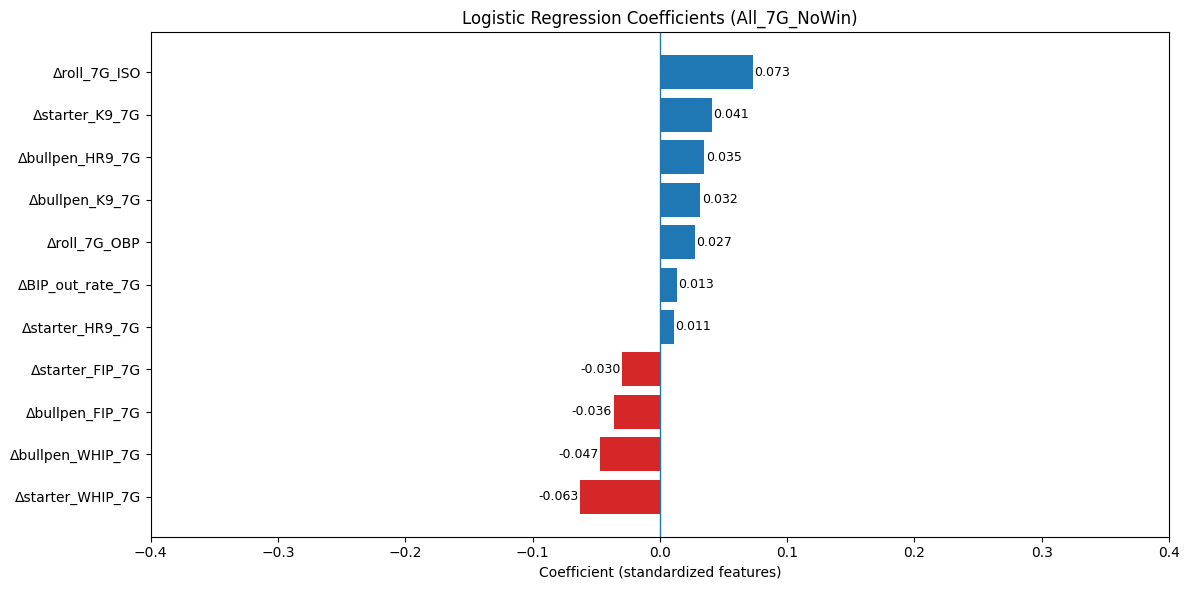

In [12]:
best_tuned = tuned_results_df.iloc[0]
best_tuned_name = best_tuned["model"]

best_tuned_artifact = tuned_models[best_tuned_name]
best_tuned_model = best_tuned_artifact["best_model"]

plot_model_feature_effects(
    best_tuned_model.named_steps["model"],
    feature_names=best_tuned_artifact["feature_names"],
    title=f"Logistic Regression Coefficients ({best_tuned_name})",
    xlim=(-0.4, 0.4),
)

#### Coefficient Interpretation


The largest positive coefficient corresponds to **rolling ISO over the previous seven games**, suggesting that recent power hitting provides the strongest positive signal for a home-team victory. Pitching metrics also play an important role: **starter strikeout rate (K/9)** and **bullpen strikeout rate** both have positive coefficients, indicating that teams generating more strikeouts relative to their opponents are more likely to win. Offensive metrics behave as expected in the tuned model as well, with **rolling OBP now appearing with a positive coefficient**, indicating that reaching base more frequently increases the probability of a home-team win.

Several run-prevention metrics appear with negative coefficients. In particular, **starter WHIP**, **bullpen WHIP**, and **FIP-based metrics** all reduce the predicted probability of a home win when they increase relative to the opponent. This is consistent with baseball intuition, as allowing more baserunners and runs generally decreases a team's chances of winning.

Unlike the baseline model, the tuned logistic regression specification does not include the recent win percentage feature. Instead, the model relies more directly on the underlying performance statistics, such as pitching effectiveness and offensive power,to capture the factors that drive game outcomes.

Overall, the coefficients indicate that **recent pitching effectiveness and power hitting are the strongest signals for predicting game outcomes**, while defensive and run, prevention metrics provide additional supporting information.

## Random Forest

Below, we train random forest models using the same feature-set combinations tested in the logistic regression analysis. We first train baseline random forest models for each feature configuration and compare their performance. The best-performing configuration then serves as the baseline specification.

Again, we perform hyperparameter tuning using grid search with time-aware cross-validation. This step allows the random forest model to optimize parameters such as tree depth, number of estimators, and minimum split sizes while preserving the chronological ordering of the baseball game data.

### Baseline Model

In [13]:
rf_results = []
rf_models = {}

for cfg in tqdm(combos, desc="Random forest feature sets"):
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)

    X_train_combo = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    X_test_combo = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    res = fit_eval_rf(
        X_train_combo,
        y_train,
        X_test_combo,
        y_test,
        verbose=False
    )

    rf_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": X_train_combo.shape[1],
        "test_accuracy": res["test_accuracy"],
        "test_roc_auc": res["test_roc_auc"],
        "test_log_loss": res["test_log_loss"],
    })

    rf_models[name] = {
        "fitted": res,
        "X_test": X_test_combo,
        "y_test": y_test,
        "feature_names": X_train_combo.columns
    }

rf_results_df = pd.DataFrame(rf_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    rf_results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    rf_results_df,
    rf_models,
    label="Best baseline random forest model"
)

Random forest feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,test_accuracy,test_roc_auc,test_log_loss
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,0.540741,0.549907,0.690714
13,All_7G_Win7G,7G,7G,7G,7G,True,12,0.531687,0.544118,0.692336
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,0.532922,0.544011,0.693504
14,All_7G_Win10G,7G,7G,7G,10G,True,12,0.528395,0.543577,0.692670
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,0.533745,0.543471,0.690857
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,0.538683,0.541807,0.694075
12,All_7G_NoWin,7G,7G,7G,None,False,11,0.534979,0.540045,0.694389
10,Pitch3_Bat7_Field7_Win7G,3G,7G,7G,7G,True,12,0.531687,0.533724,0.694803
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,0.525926,0.532975,0.694170
3,Pitch7_Bat3_Field3_NoWin,7G,3G,3G,None,False,11,0.525514,0.530381,0.695423


Best baseline random forest model: Pitch7_Bat7_Field3_Win10G
Test Accuracy: 0.5407
Test ROC AUC:  0.5499
Test Log Loss: 0.6907

Confusion Matrix:
 [[521 590]
 [526 793]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.47      0.48      1111
           1       0.57      0.60      0.59      1319

    accuracy                           0.54      2430
   macro avg       0.54      0.54      0.53      2430
weighted avg       0.54      0.54      0.54      2430



### Analysis

**TODO**: Add analysis

### Random Forest Baseline Coefficient Plot

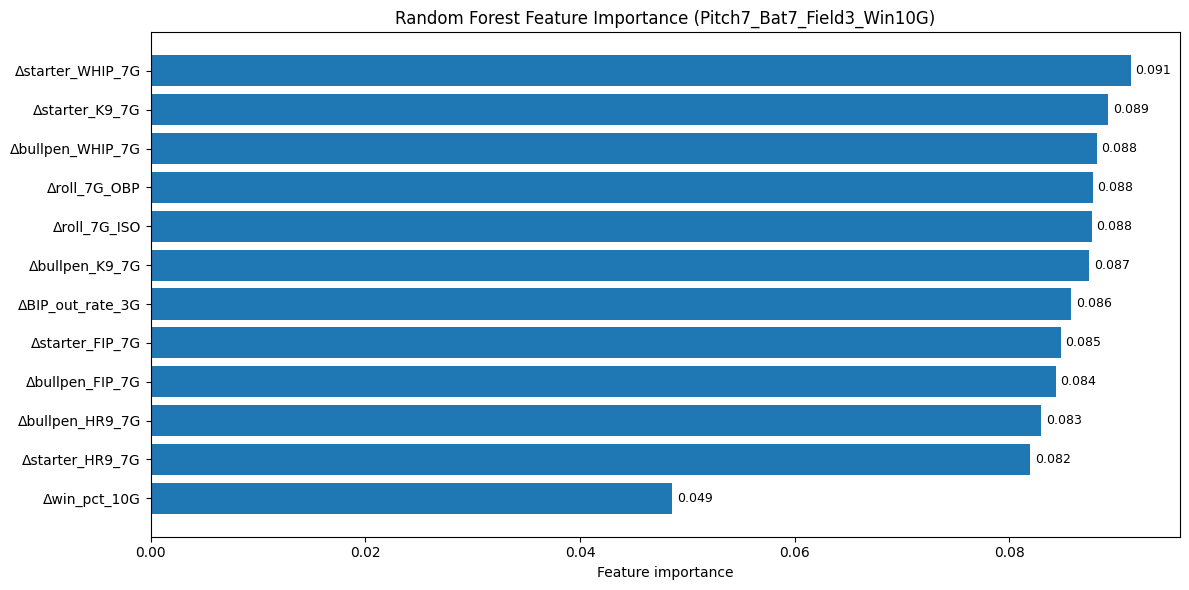

In [14]:
best_rf = rf_results_df.iloc[0]
best_rf_name = best_rf["model"]

best_rf_artifact = rf_models[best_rf_name]
best_rf_model = best_rf_artifact["fitted"]["model"]

plot_model_feature_effects(
    best_rf_model,
    feature_names=best_rf_artifact["feature_names"],
    title=f"Random Forest Feature Importance ({best_rf_name})"
)

### Hyperparameter Tuning with Grid Search

Again, we use grid search with time-aware cross-validation to tune each random forest feature set. The goal of this step is to identify the combination of hyperparameters that produces the strongest predictive performance within each feature configuration.

For each feature set, the grid search evaluates different values for the number of trees, maximum tree depth, minimum samples required for a split, minimum samples required at a leaf, and class weighting. Model performance is assessed using `TimeSeriesSplit`, which preserves the chronological ordering of the baseball game data.

For each feature set, the model with the highest cross-validated ROC-AUC is selected, then refit on the full training data and evaluated on the held-out test set.

In [29]:
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4],
    "max_features": ["sqrt"],
    "class_weight": [None, "balanced"]
}

In [30]:
rf_param_list = list(ParameterGrid(param_grid_rf))

rf_tuned_results = []
rf_tuned_models = {}

outer_pbar = tqdm(combos, desc="Tuning RF feature sets")

for cfg in outer_pbar:
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)
    outer_pbar.set_postfix(model=name)

    X_train_combo = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    X_test_combo = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    best_cv_auc = -np.inf
    best_params = None
    best_model = None

    inner_pbar = tqdm(
        rf_param_list,
        desc=f"{name}",
        leave=False
    )

    for params in inner_pbar:
        fold_aucs = []

        for train_idx, val_idx in tscv.split(X_train_combo):
            X_tr = X_train_combo.iloc[train_idx]
            X_val = X_train_combo.iloc[val_idx]
            y_tr = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
            y_val = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

            rf = RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                **params
            )

            rf.fit(X_tr, y_tr)
            y_val_proba = rf.predict_proba(X_val)[:, 1]
            fold_auc = roc_auc_score(y_val, y_val_proba)
            fold_aucs.append(fold_auc)

        mean_cv_auc = np.mean(fold_aucs)

        inner_pbar.set_postfix(
            cv_auc=f"{mean_cv_auc:.4f}",
            trees=params["n_estimators"],
            depth=params["max_depth"]
        )

        if mean_cv_auc > best_cv_auc:
            best_cv_auc = mean_cv_auc
            best_params = params

    # Refit best model on full training set
    best_model = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **best_params
    )
    best_model.fit(X_train_combo, y_train)

    y_pred = best_model.predict(X_test_combo)
    y_proba = best_model.predict_proba(X_test_combo)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    ll = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    rf_tuned_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": X_train_combo.shape[1],
        "best_n_estimators": best_params["n_estimators"],
        "best_max_depth": best_params["max_depth"],
        "best_min_samples_split": best_params["min_samples_split"],
        "best_min_samples_leaf": best_params["min_samples_leaf"],
        "best_max_features": best_params["max_features"],
        "best_class_weight": best_params["class_weight"],
        "cv_roc_auc": best_cv_auc,
        "test_accuracy": acc,
        "test_roc_auc": auc,
        "test_log_loss": ll
    })

    rf_tuned_models[name] = {
        "best_model": best_model,
        "X_test": X_test_combo,
        "y_test": y_test,
        "feature_names": X_train_combo.columns,
        "confusion_matrix": cm,
        "classification_report": report,
        "best_params": best_params
    }

rf_tuned_results_df = pd.DataFrame(rf_tuned_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    rf_tuned_results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features",
            "best_n_estimators", "best_max_depth", "best_min_samples_split",
            "best_min_samples_leaf", "best_max_features", "best_class_weight",
            "cv_roc_auc", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    rf_tuned_results_df,
    rf_tuned_models,
    label="Best tuned random forest model"
)

Tuning RF feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

All_3G_NoWin:   0%|          | 0/48 [00:00<?, ?it/s]

All_3G_Win7G:   0%|          | 0/48 [00:00<?, ?it/s]

All_3G_Win10G:   0%|          | 0/48 [00:00<?, ?it/s]

Pitch7_Bat3_Field3_NoWin:   0%|          | 0/48 [00:00<?, ?it/s]

...

All_7G_NoWin:   0%|          | 0/48 [00:00<?, ?it/s]

All_7G_Win7G:   0%|          | 0/48 [00:00<?, ?it/s]

All_7G_Win10G:   0%|          | 0/48 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,best_n_estimators,best_max_depth,best_min_samples_split,best_min_samples_leaf,best_max_features,best_class_weight,cv_roc_auc,test_accuracy,test_roc_auc,test_log_loss
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,400,5,10,1,sqrt,None,0.561366,0.547325,0.556693,0.685052
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,400,5,10,4,sqrt,None,0.557631,0.554733,0.556580,0.684946
14,All_7G_Win10G,7G,7G,7G,10G,True,12,400,5,10,1,sqrt,None,0.562357,0.551029,0.555808,0.685063
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,400,5,2,4,sqrt,None,0.560576,0.551440,0.555207,0.685193
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,200,5,10,4,sqrt,None,0.555375,0.549794,0.554437,0.685072
3,Pitch7_Bat3_Field3_NoWin,7G,3G,3G,None,False,11,200,5,2,1,sqrt,None,0.553935,0.549794,0.554178,0.685003
13,All_7G_Win7G,7G,7G,7G,7G,True,12,400,5,10,1,sqrt,None,0.560927,0.547325,0.553886,0.685228
12,All_7G_NoWin,7G,7G,7G,None,False,11,200,5,10,4,sqrt,None,0.559904,0.546502,0.552464,0.685585
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,200,5,10,1,sqrt,None,0.560334,0.544856,0.552082,0.685752
11,Pitch3_Bat7_Field7_Win10G,3G,7G,7G,10G,True,12,200,5,2,1,sqrt,balanced,0.555971,0.533333,0.547777,0.689348


Best tuned random forest model: Pitch7_Bat7_Field3_Win10G
Test Accuracy: 0.5473
Test ROC AUC:  0.5567
Test Log Loss: 0.6851

Confusion Matrix:
 [[434 677]
 [423 896]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.39      0.44      1111
           1       0.57      0.68      0.62      1319

    accuracy                           0.55      2430
   macro avg       0.54      0.53      0.53      2430
weighted avg       0.54      0.55      0.54      2430



### Tuned Random Forest Results

The best-performing tuned random forest configuration was `Pitch7_Bat7_Field3_Win10G`. This model used 7-game rolling windows for pitching and batting metrics, a 3-game window for fielding metrics, and included the 10-game win percentage feature. The tuned model achieved a **test ROC-AUC of 0.5567**, **accuracy of 54.7%**, and **log loss of 0.6851**.

Overall, the results show a similar pattern to the logistic regression experiments. Models that relied on **7-game rolling windows for pitching and batting** tended to perform better than those using only 3-game windows, suggesting that slightly longer performance windows provide more stable predictive signal. Many of the stronger configurations also included recent win percentage features, though the gains were relatively modest.

Despite the additional flexibility of the random forest model, it did **not outperform the tuned logistic regression model**. The best logistic regression model achieved a slightly higher ROC-AUC (**0.5618**) and accuracy (**56.5%**). This suggests that the relationship between the engineered features and game outcomes may be captured well by a relatively simple linear model once the features are properly constructed.

The classification results also show that the model performs better at identifying **home-team wins** than away-team wins. This likely reflects the slight home-field advantage present in Major League Baseball as well as the overall class distribution in the dataset.

Taken together, these results indicate that while ensemble methods like random forests can model more complex interactions, the carefully engineered rolling performance metrics already capture much of the available predictive signal. As a result, the simpler tuned logistic regression model remains the preferred specification for the final analysis.

### Best Tuned Random Forest Model Coefficents

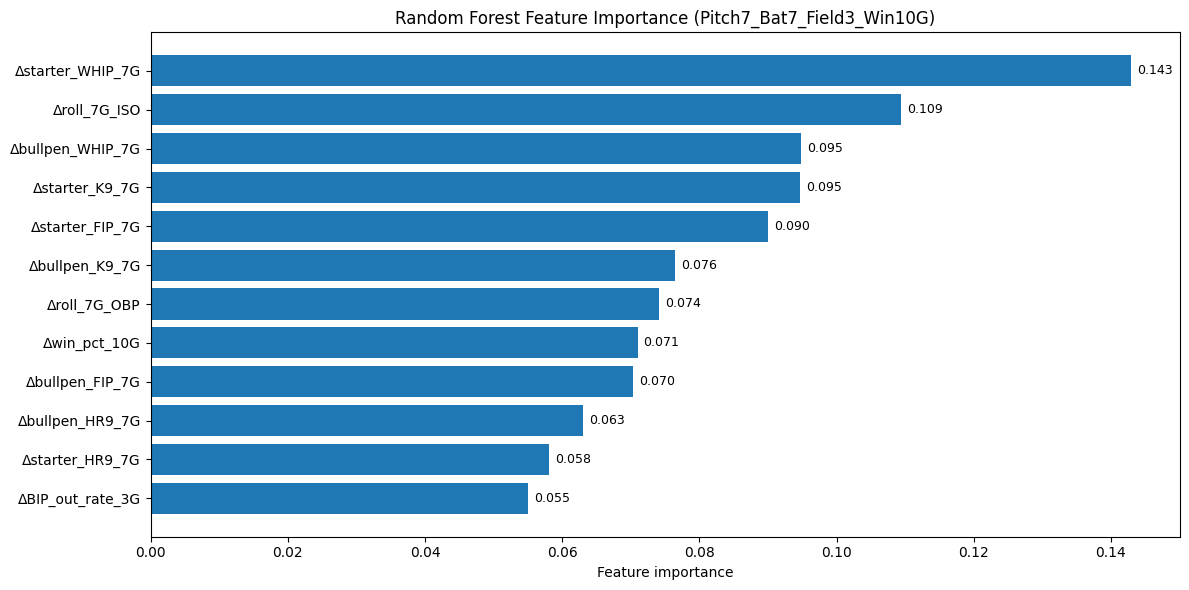

In [31]:
best_rf_tuned = rf_tuned_results_df.iloc[0]
best_rf_tuned_name = best_rf_tuned["model"]

best_rf_tuned_artifact = rf_tuned_models[best_rf_tuned_name]
best_rf_tuned_model = best_rf_tuned_artifact["best_model"]

plot_model_feature_effects(
    best_rf_tuned_model,
    feature_names=best_rf_tuned_artifact["feature_names"],
    title=f"Random Forest Feature Importance ({best_rf_tuned_name})"
)

# CONTINUE EDITING HERE!

## XGBoost

Below, we train XGBoost models using the same feature-set combinations evaluated in the previous sections. We will first train a baseline model and use the best-performing configuration as the baseline specification.

After, we perform hyperparameter tuning using grid search with time-aware cross-validation. This step allows the XGBoost model to optimize parameters such as the number of trees, learning rate, tree depth, and sampling parameters while preserving the chronological structure of the baseball game data.

### Baseline Model

In [15]:
xgb_results = []
xgb_models = {}

for cfg in tqdm(combos, desc="XGBoost feature sets"):
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)

    X_train_combo = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    X_test_combo = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    res = fit_eval_xgb(
        X_train_combo,
        y_train,
        X_test_combo,
        y_test,
        verbose=False
    )

    xgb_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": X_train_combo.shape[1],
        "test_accuracy": res["test_accuracy"],
        "test_roc_auc": res["test_roc_auc"],
        "test_log_loss": res["test_log_loss"],
    })

    xgb_models[name] = {
        "fitted": res,
        "X_test": X_test_combo,
        "y_test": y_test,
        "feature_names": X_train_combo.columns
    }

xgb_results_df = pd.DataFrame(xgb_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    xgb_results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    xgb_results_df,
    xgb_models,
    label="Best baseline XGB model"
)


XGBoost feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,test_accuracy,test_roc_auc,test_log_loss
14,All_7G_Win10G,7G,7G,7G,10G,True,12,0.537037,0.545997,0.697303
13,All_7G_Win7G,7G,7G,7G,7G,True,12,0.543210,0.545907,0.696368
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,0.530041,0.543815,0.697085
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,0.541975,0.542724,0.696785
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,0.534979,0.539313,0.695681
3,Pitch7_Bat3_Field3_NoWin,7G,3G,3G,None,False,11,0.528395,0.538399,0.695694
12,All_7G_NoWin,7G,7G,7G,None,False,11,0.537860,0.537722,0.698285
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,0.534156,0.535451,0.699430
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,0.530864,0.534997,0.700389
10,Pitch3_Bat7_Field7_Win7G,3G,7G,7G,7G,True,12,0.523045,0.522723,0.702382


Best baseline XGB model: All_7G_Win10G
Test Accuracy: 0.5370
Test ROC AUC:  0.5460
Test Log Loss: 0.6973

Confusion Matrix:
 [[495 616]
 [509 810]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.45      0.47      1111
           1       0.57      0.61      0.59      1319

    accuracy                           0.54      2430
   macro avg       0.53      0.53      0.53      2430
weighted avg       0.53      0.54      0.53      2430



### Baseline XGBoost Results

ADD ANALYSIS

### XGBoost Baseline Coefficient Plot

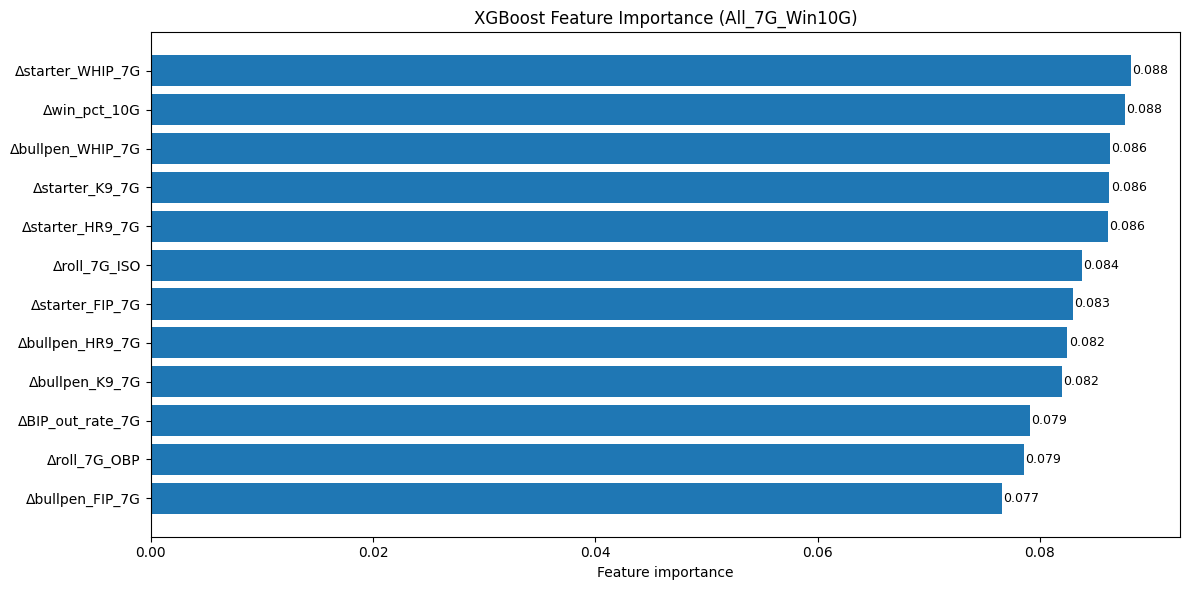

In [16]:
best_xgb = xgb_results_df.iloc[0]
best_xgb_name = best_xgb["model"]

best_xgb_artifact = xgb_models[best_xgb_name]
best_xgb_model = best_xgb_artifact["fitted"]["model"]

plot_model_feature_effects(
    best_xgb_model,
    feature_names=best_xgb_artifact["feature_names"],
    title=f"XGBoost Feature Importance ({best_xgb_name})"
)

### Add Results

### Hyperparameter Tuning with Grid Search

As in the previous models, we tune the XGBoost feature sets using grid search with time-aware cross-validation. The grid search evaluates combinations of key hyperparameters, including the number of trees, learning rate, tree depth, and sampling parameters.

Model performance is evaluated using `TimeSeriesSplit` to preserve the chronological structure of the baseball game data. For each feature set, the model with the highest cross-validated ROC-AUC is selected, then fit on the full training data and evaluated on the held-out test set.

In [ ]:
param_grid_xgb = {
    "n_estimators": [200, 400],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0]
}


In [17]:
xgb_param_list = list(ParameterGrid(param_grid_xgb))

xgb_tuned_results = []
xgb_tuned_models = {}

outer_pbar = tqdm(combos, desc="Tuning XGBoost feature sets")

for cfg in outer_pbar:
    name = cfg["name"]
    win_map = cfg["windows"]
    include_win = cfg.get("include_win", True)
    outer_pbar.set_postfix(model=name)

    X_train_combo = build_feature_set(
        train_df,
        windows=win_map,
        include_win=include_win
    )
    X_test_combo = build_feature_set(
        test_df,
        windows=win_map,
        include_win=include_win
    )

    best_cv_auc = -np.inf
    best_params = None
    best_model = None

    inner_pbar = tqdm(
        xgb_param_list,
        desc=f"{name}",
        leave=False
    )

    for params in inner_pbar:
        fold_aucs = []

        for train_idx, val_idx in tscv.split(X_train_combo):
            X_tr = X_train_combo.iloc[train_idx]
            X_val = X_train_combo.iloc[val_idx]
            y_tr = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
            y_val = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

            xgb = XGBClassifier(
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1,
                **params
            )

            xgb.fit(X_tr, y_tr)
            y_val_proba = xgb.predict_proba(X_val)[:, 1]
            fold_auc = roc_auc_score(y_val, y_val_proba)
            fold_aucs.append(fold_auc)

        mean_cv_auc = np.mean(fold_aucs)

        inner_pbar.set_postfix(
            cv_auc=f"{mean_cv_auc:.4f}",
            trees=params["n_estimators"],
            depth=params["max_depth"]
        )

        if mean_cv_auc > best_cv_auc:
            best_cv_auc = mean_cv_auc
            best_params = params

    # Refit best model on full training set
    best_model = XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        **best_params
    )
    best_model.fit(X_train_combo, y_train)

    y_pred = best_model.predict(X_test_combo)
    y_proba = best_model.predict_proba(X_test_combo)[:, 1]

    test_accuracy = accuracy_score(y_test, y_pred)
    test_roc_auc = roc_auc_score(y_test, y_proba)
    test_log_loss = log_loss(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    xgb_tuned_results.append({
        "model": name,
        "pitch_w": win_map["pitch"],
        "bat_w": win_map["bat"],
        "field_w": win_map["field"],
        "win_w": win_map.get("win", None),
        "include_win": include_win,
        "n_features": X_train_combo.shape[1],
        "best_n_estimators": best_params["n_estimators"],
        "best_learning_rate": best_params["learning_rate"],
        "best_max_depth": best_params["max_depth"],
        "best_subsample": best_params["subsample"],
        "best_colsample_bytree": best_params["colsample_bytree"],
        "best_reg_lambda": best_params["reg_lambda"],
        "cv_roc_auc": best_cv_auc,
        "test_accuracy": test_accuracy,
        "test_roc_auc": test_roc_auc,
        "test_log_loss": test_log_loss
    })

    xgb_tuned_models[name] = {
        "best_model": best_model,
        "X_test": X_test_combo,
        "y_test": y_test,
        "feature_names": X_train_combo.columns,
        "confusion_matrix": cm,
        "classification_report": report,
        "best_params": best_params
    }

xgb_tuned_results_df = pd.DataFrame(xgb_tuned_results).sort_values(
    by=["test_roc_auc", "test_log_loss"],
    ascending=[False, True]
)

display(
    xgb_tuned_results_df[
        [
            "model", "pitch_w", "bat_w", "field_w", "win_w", "include_win",
            "n_features",
            "best_n_estimators", "best_learning_rate", "best_max_depth",
            "best_subsample", "best_colsample_bytree", "best_reg_lambda",
            "cv_roc_auc", "test_accuracy", "test_roc_auc", "test_log_loss"
        ]
    ]
)

print_best_model_report(
    xgb_tuned_results_df,
    xgb_tuned_models,
    label="Best tuned XGBoost model"
)

Tuning XGBoost feature sets:   0%|          | 0/15 [00:00<?, ?it/s]

All_3G_NoWin:   0%|          | 0/96 [00:00<?, ?it/s]

All_3G_Win7G:   0%|          | 0/96 [00:00<?, ?it/s]

All_3G_Win10G:   0%|          | 0/96 [00:00<?, ?it/s]

Pitch7_Bat3_Field3_NoWin:   0%|          | 0/96 [00:00<?, ?it/s]

...

All_7G_NoWin:   0%|          | 0/96 [00:00<?, ?it/s]

All_7G_Win7G:   0%|          | 0/96 [00:00<?, ?it/s]

All_7G_Win10G:   0%|          | 0/96 [00:00<?, ?it/s]

,model,pitch_w,bat_w,field_w,win_w,include_win,n_features,best_n_estimators,best_learning_rate,best_max_depth,best_subsample,best_colsample_bytree,best_reg_lambda,cv_roc_auc,test_accuracy,test_roc_auc,test_log_loss
5,Pitch7_Bat3_Field3_Win10G,7G,3G,3G,10G,True,12,200,0.03,3,0.8,0.8,5.0,0.553180,0.555967,0.557927,0.685827
3,Pitch7_Bat3_Field3_NoWin,7G,3G,3G,None,False,11,200,0.03,3,0.8,0.8,5.0,0.546881,0.548560,0.553572,0.686131
14,All_7G_Win10G,7G,7G,7G,10G,True,12,200,0.03,3,0.8,0.8,5.0,0.557513,0.542798,0.550076,0.687219
12,All_7G_NoWin,7G,7G,7G,None,False,11,200,0.03,3,0.8,1.0,5.0,0.554918,0.538272,0.548489,0.687640
13,All_7G_Win7G,7G,7G,7G,7G,True,12,200,0.03,3,0.8,1.0,5.0,0.555361,0.541564,0.547893,0.687692
8,Pitch7_Bat7_Field3_Win10G,7G,7G,3G,10G,True,12,200,0.03,3,0.8,0.8,5.0,0.554628,0.540741,0.547180,0.688143
7,Pitch7_Bat7_Field3_Win7G,7G,7G,3G,7G,True,12,200,0.03,3,0.8,1.0,5.0,0.552095,0.533745,0.545262,0.688294
6,Pitch7_Bat7_Field3_NoWin,7G,7G,3G,None,False,11,200,0.03,3,0.8,1.0,5.0,0.552146,0.538683,0.544915,0.688533
4,Pitch7_Bat3_Field3_Win7G,7G,3G,3G,7G,True,12,200,0.05,3,0.8,0.8,5.0,0.546160,0.539918,0.542582,0.690344
1,All_3G_Win7G,3G,3G,3G,7G,True,12,200,0.03,3,1.0,0.8,1.0,0.550429,0.530864,0.542118,0.688941


Best tuned XGBoost model: Pitch7_Bat3_Field3_Win10G
Test Accuracy: 0.5560
Test ROC AUC:  0.5579
Test Log Loss: 0.6858

Confusion Matrix:
 [[459 652]
 [427 892]]

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.41      0.46      1111
           1       0.58      0.68      0.62      1319

    accuracy                           0.56      2430
   macro avg       0.55      0.54      0.54      2430
weighted avg       0.55      0.56      0.55      2430



### XGBoost Tuned Coefficient Plot

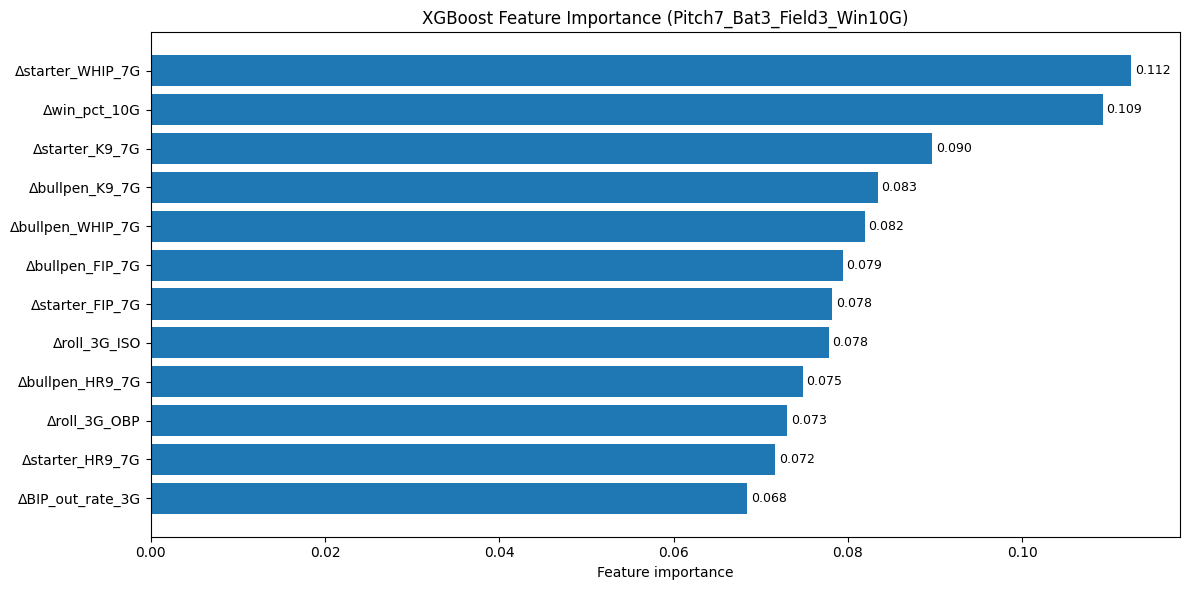

In [18]:
best_xgb_tuned = xgb_tuned_results_df.iloc[0]
best_xgb_tuned_name = best_xgb_tuned["model"]

best_xgb_tuned_artifact = xgb_tuned_models[best_xgb_tuned_name]
best_xgb_tuned_model = best_xgb_tuned_artifact["best_model"]

plot_model_feature_effects(
    best_xgb_tuned_model,
    feature_names=best_xgb_tuned_artifact["feature_names"],
    title=f"XGBoost Feature Importance ({best_xgb_tuned_name})"
)

# TODO: ADD ANALYSIS

# TODO: HAVE CONCLUSION